In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import seaborn as sns

import scanpy as sc
import scvi


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

# Load Data

## Load entropy results

In [2]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'

Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)


,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


# RNA clustering

In [3]:
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')

h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
h5_rna_union, h5_rna_union.shape 

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [5]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)


# Normalization for visualization
h5_rna_union.layers['log1p_counts'] = np.log1p(h5_rna_union.X)
h5_rna_union.layers['cpm'] = sc.pp.normalize_total(h5_rna_union, target_sum=1e4, inplace=False)['X']
h5_rna_union.layers['log1p_cpm'] = np.log1p(h5_rna_union.layers['cpm'])

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [6]:
SCVI_LATENT_KEY = "RNA_scVI_unionBC"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_unionBC"


vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()



# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.5)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unioncells_RNA_scvi_model/model.pt      
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/torch/cuda/__init__.py:905: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  r = torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (S

### Vis on RNA spcae

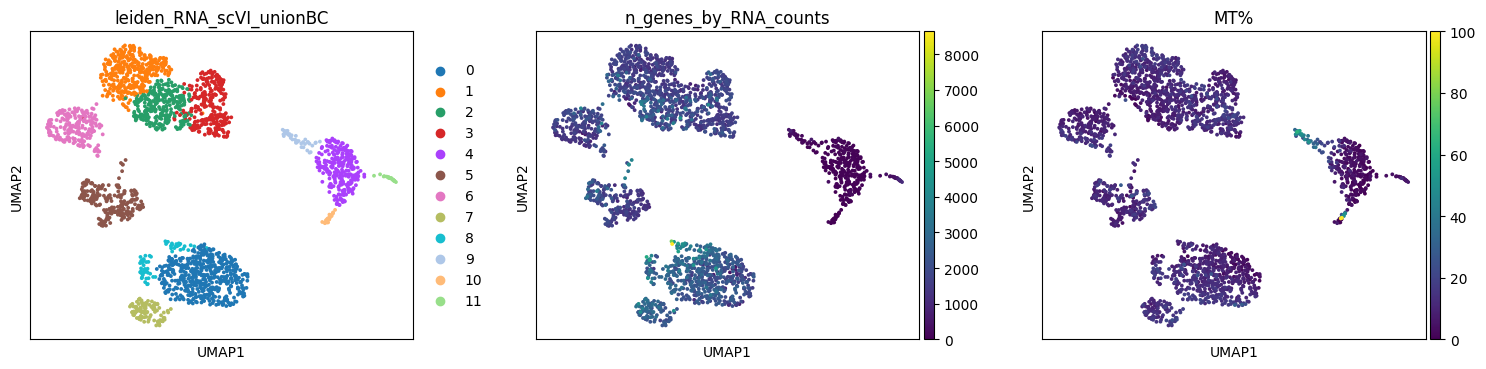

In [7]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI_unionBC',  'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=3)

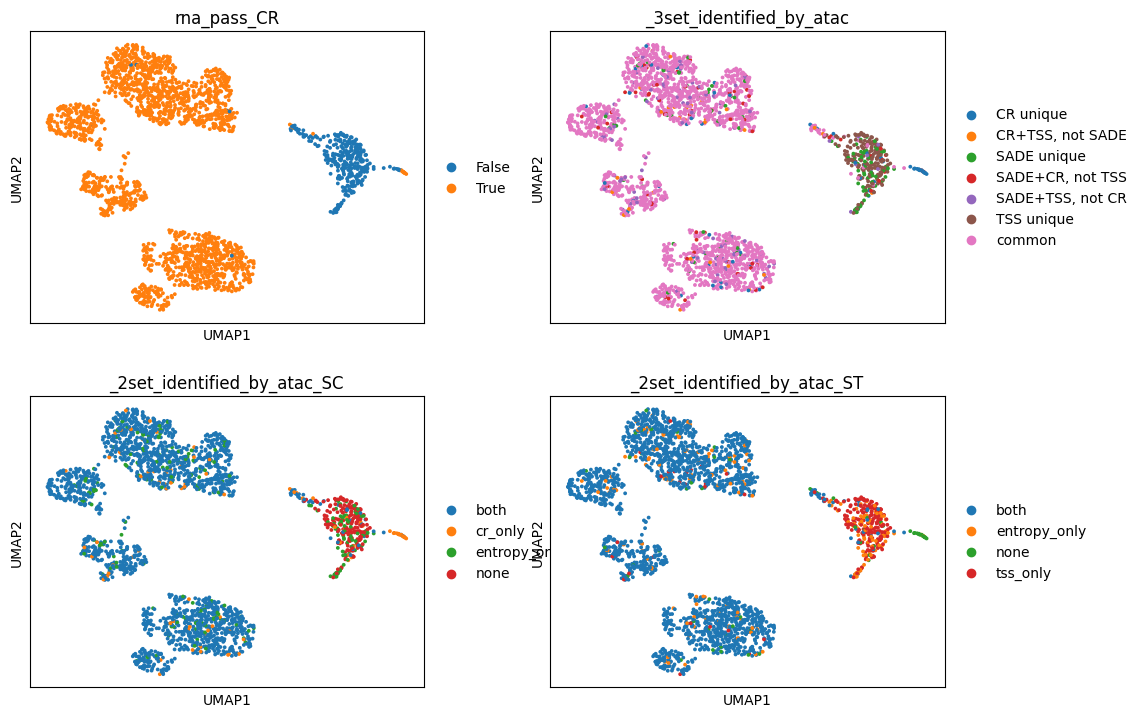

In [8]:
col_list = ['_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 
            'rna_pass_CR']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(union_cell_info[col])

with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=[
                              'rna_pass_CR', '_3set_identified_by_atac',
                              '_2set_identified_by_atac_SC',
                                    '_2set_identified_by_atac_ST',   ] , wspace=0.2, size=30, ncols=2)

In [9]:
h5_rna_union

AnnData object with n_obs × n_vars = 2381 × 21805
    obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%', '_scvi_batch', '_scvi_labels', 'leiden_RNA_scVI_unionBC', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'rna_pass_CR'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden_RNA_scVI_unionBC', 'leiden_RNA_scVI_unionBC_colors', 'rna_pass_CR_colors', '_3set_identified_by_atac_colors', '_2set_identified_by_atac_SC_colors', '_2set_identified_by_atac_ST_colors'
    obsm: 'RNA_scVI_unionBC', 'X_umap'
    layers: 'counts', 'log1p_counts', 'cpm', 'log1p_cpm'
    obsp: 'distances', 'connectivities'

In [11]:
Tcells= ['IL7R',] #'CD3G', 'CD3E', 'CD3D',  ] 
B_cell = ['MS4A1', 'CD79A']# , 'CD19', ]
NK = [ 'FCGR3A', 'NCAM1'] # NKG7',FCGR3A', 'NCAM1'
mono = [ 'CD14',   'CD68',   ]# ,  CD14, FCGR1A, CD68
naiveTcells = [ "CCR7",	  ]#  "CCR7",	 'IL7R',
DC=[  'CD1C',    'SERPINF1']
cytotoxic_T = ['CD8A', 'CD8B',]
mono_or_DC = ['HLA-DRA'] # for umap 
naiveThelper = [   'CD4', ] # for umap 

housekeeping_genes = ['GNB1', 'PRPF38B',  'CDC42SE1', 'PPP2R5A',] # 'CMPK1', 'COX7A2L', 'SF3B1', 'CTDSP1']

marker_genes =Tcells  + naiveTcells +  cytotoxic_T+  NK+ mono + DC + B_cell    + mono_or_DC + naiveThelper + housekeeping_genes 

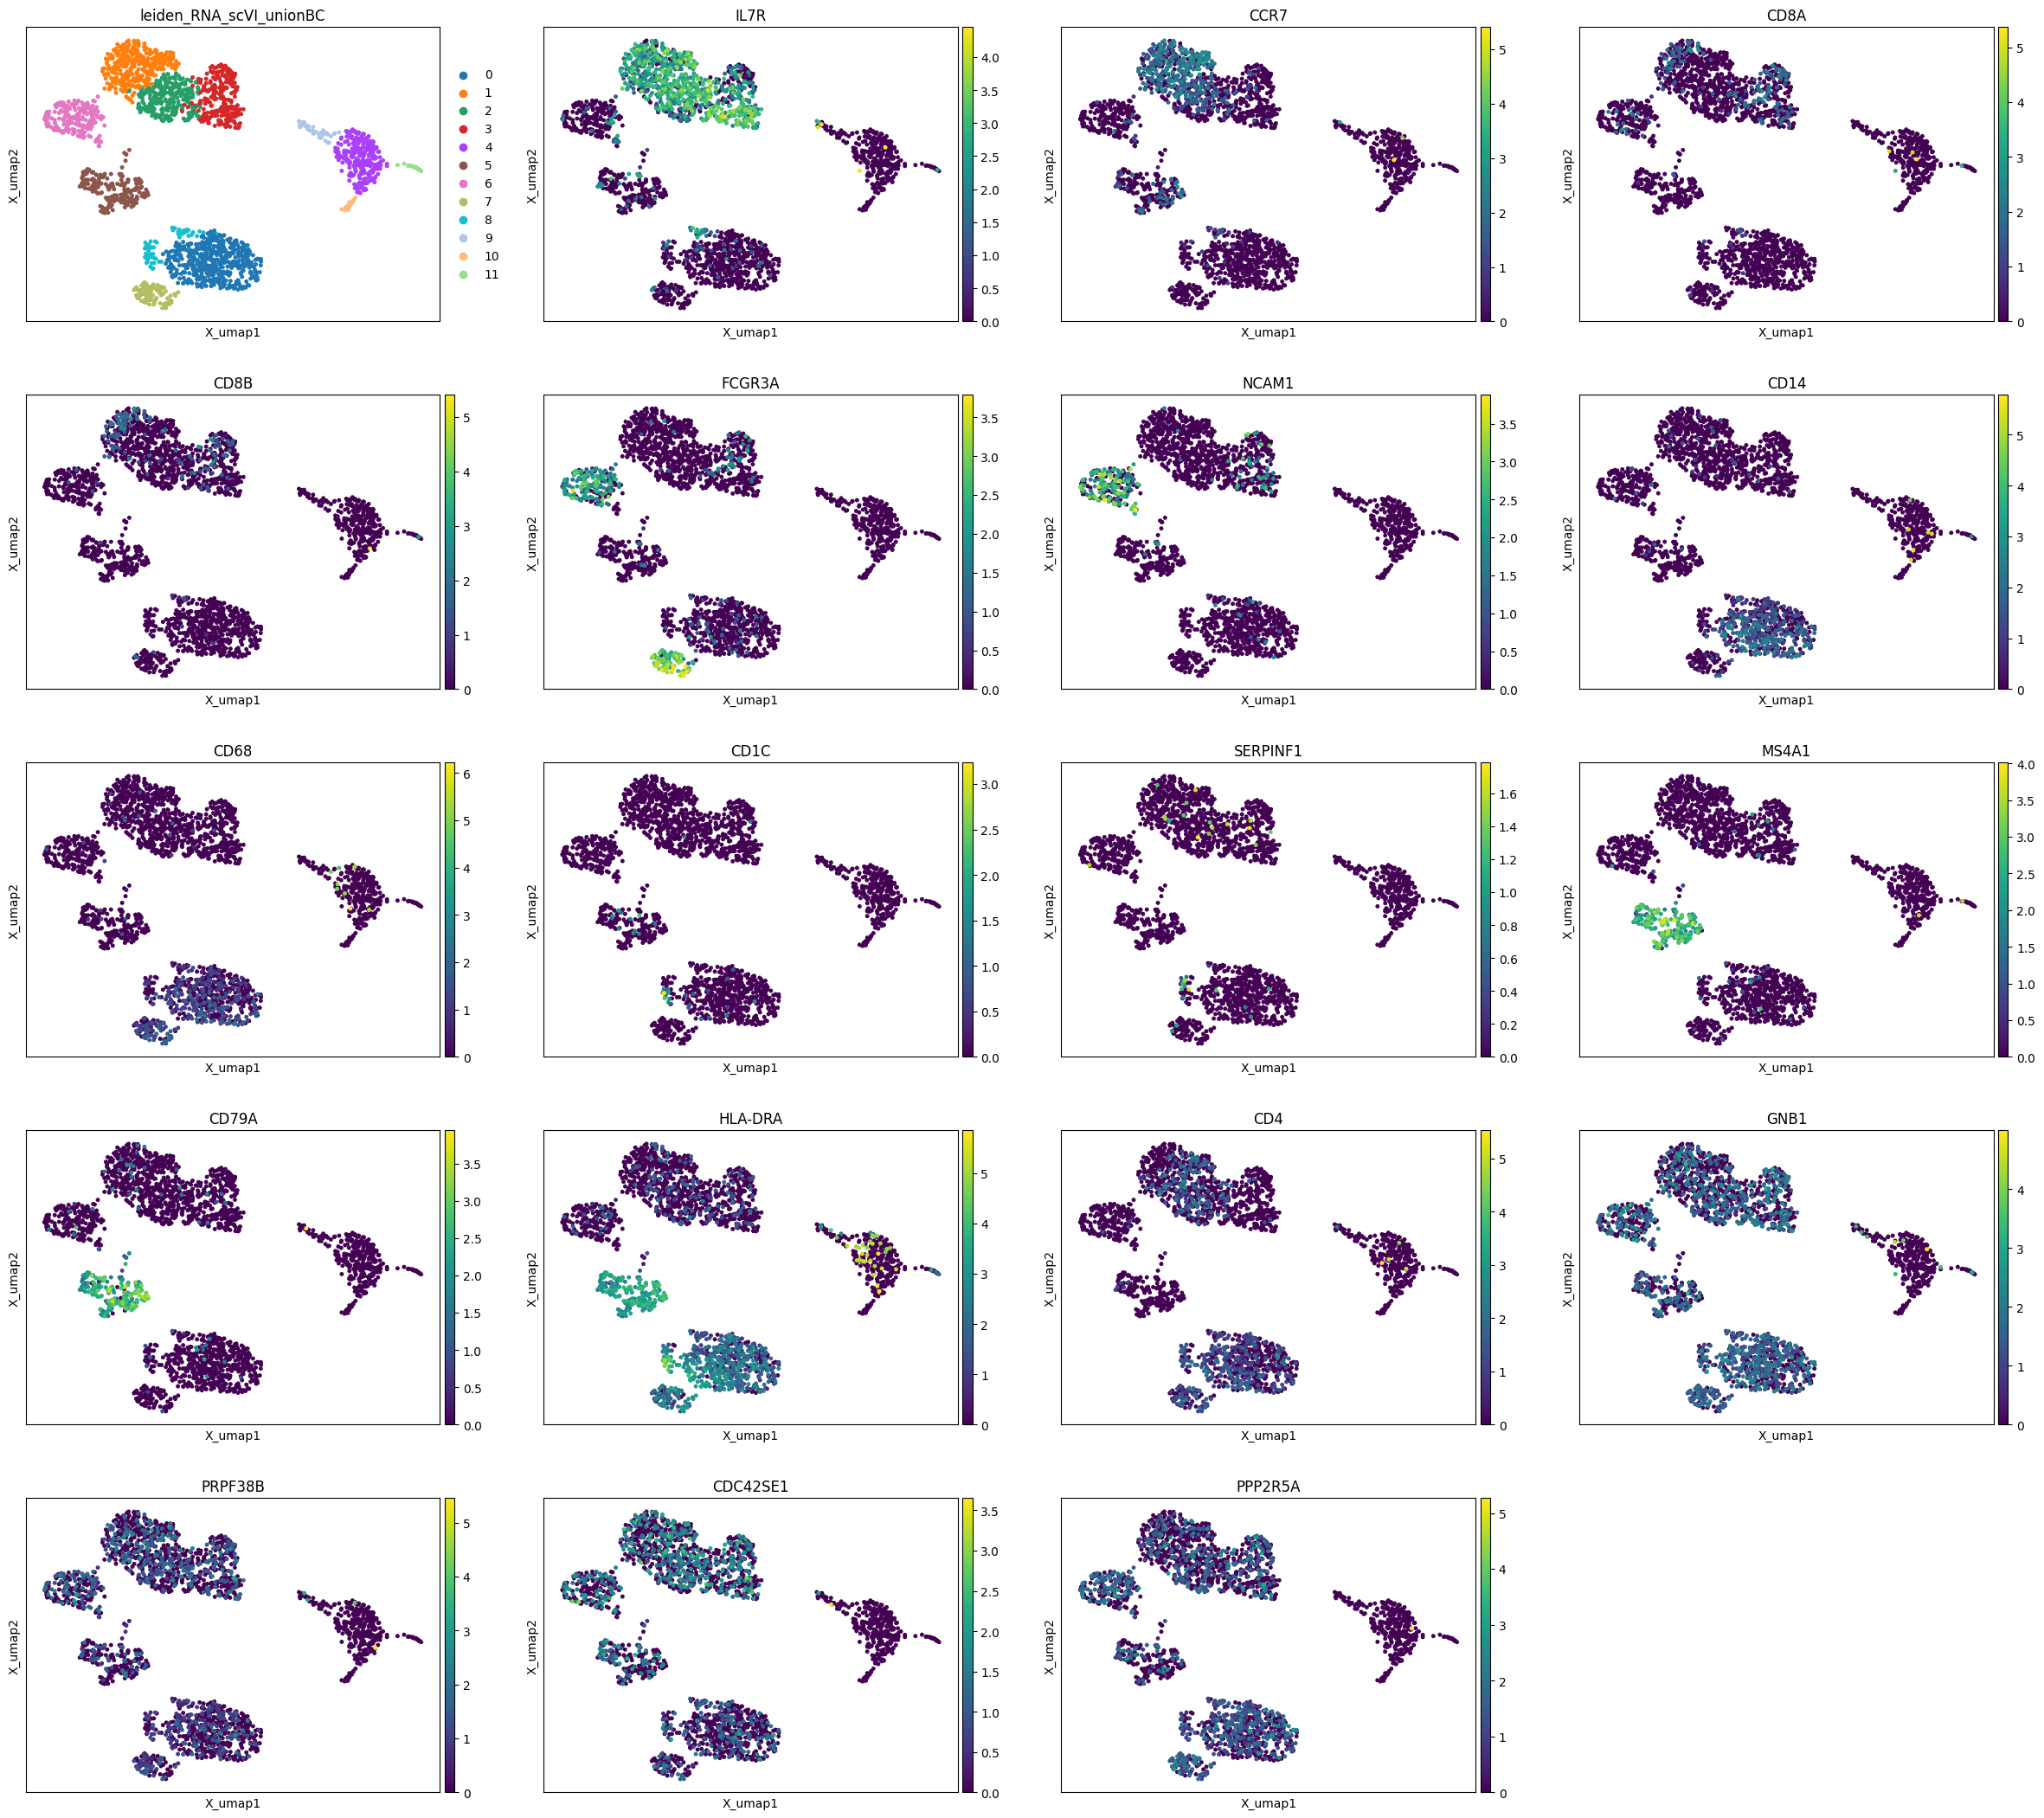

In [12]:

sc.pl.embedding(h5_rna_union, basis="X_umap", layer='log1p_cpm', color=["leiden_RNA_scVI_unionBC",] + \
     marker_genes)

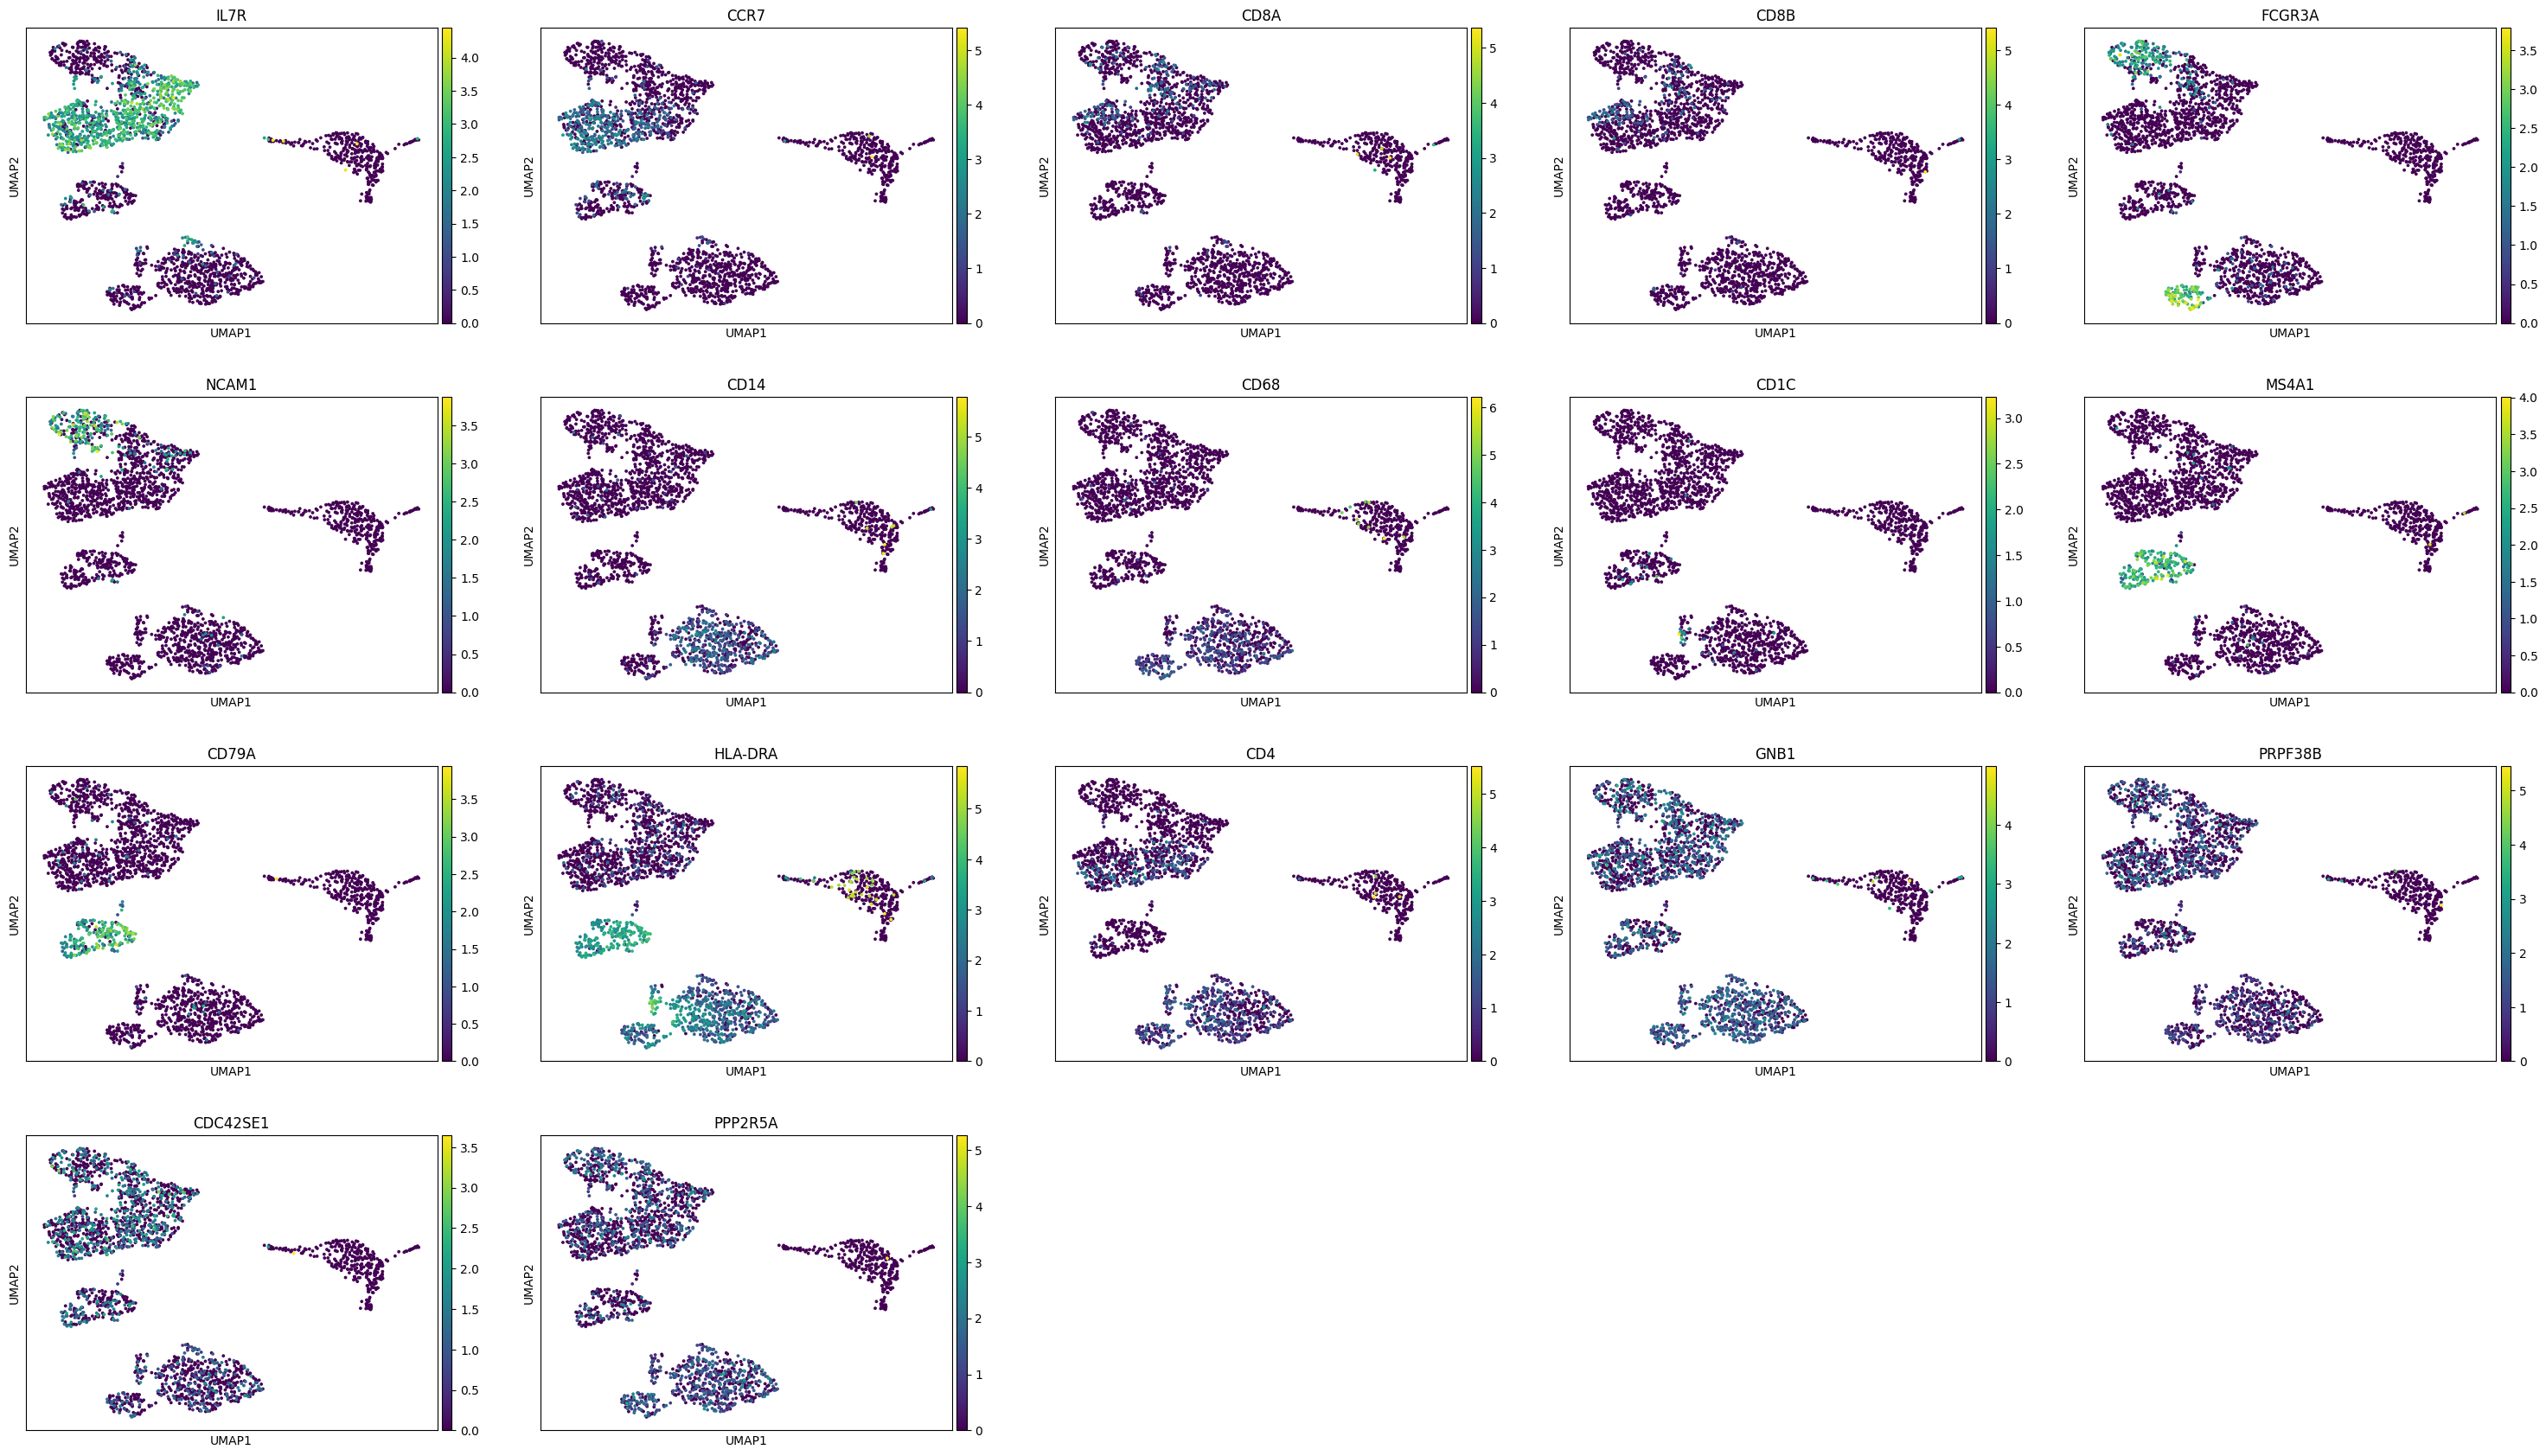

In [ ]:
sc.pl.umap(h5_rna_union, color=marker_genes,  layer='log1p_cpm', size=30, ncols=5)

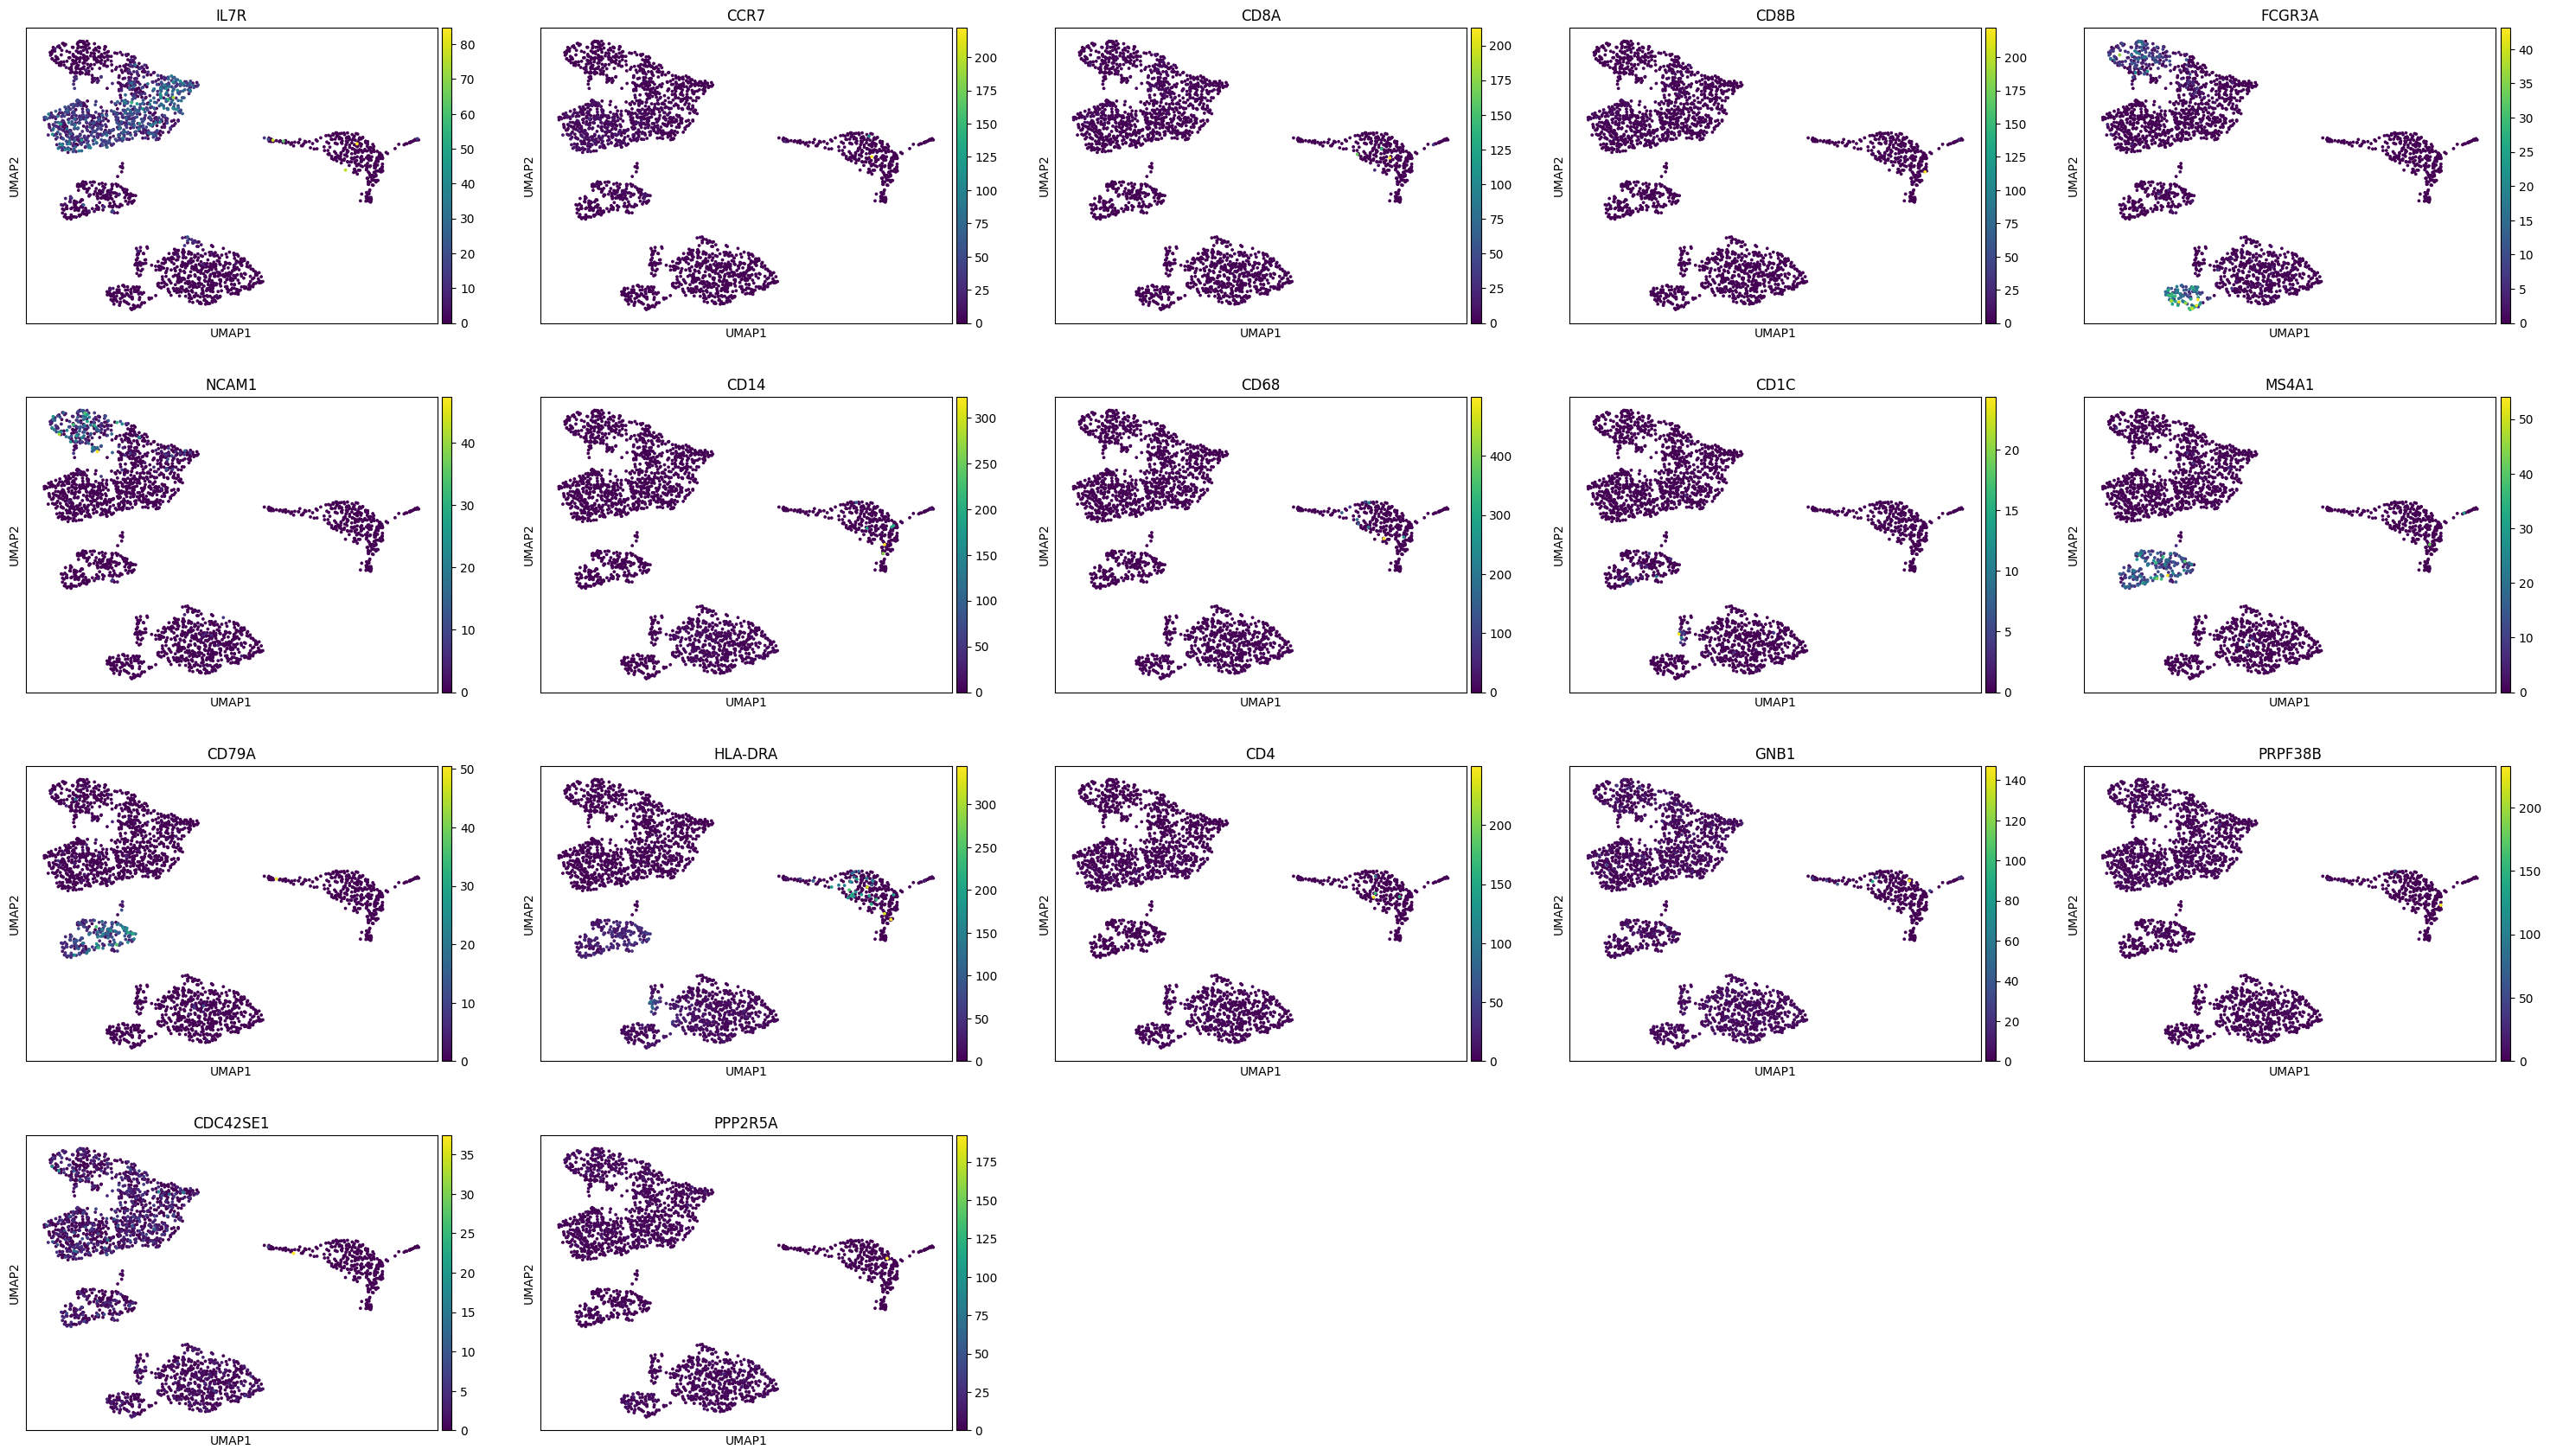

In [13]:

sc.pl.umap(h5_rna_union, color=marker_genes,  layer='cpm', size=30, ncols=5)

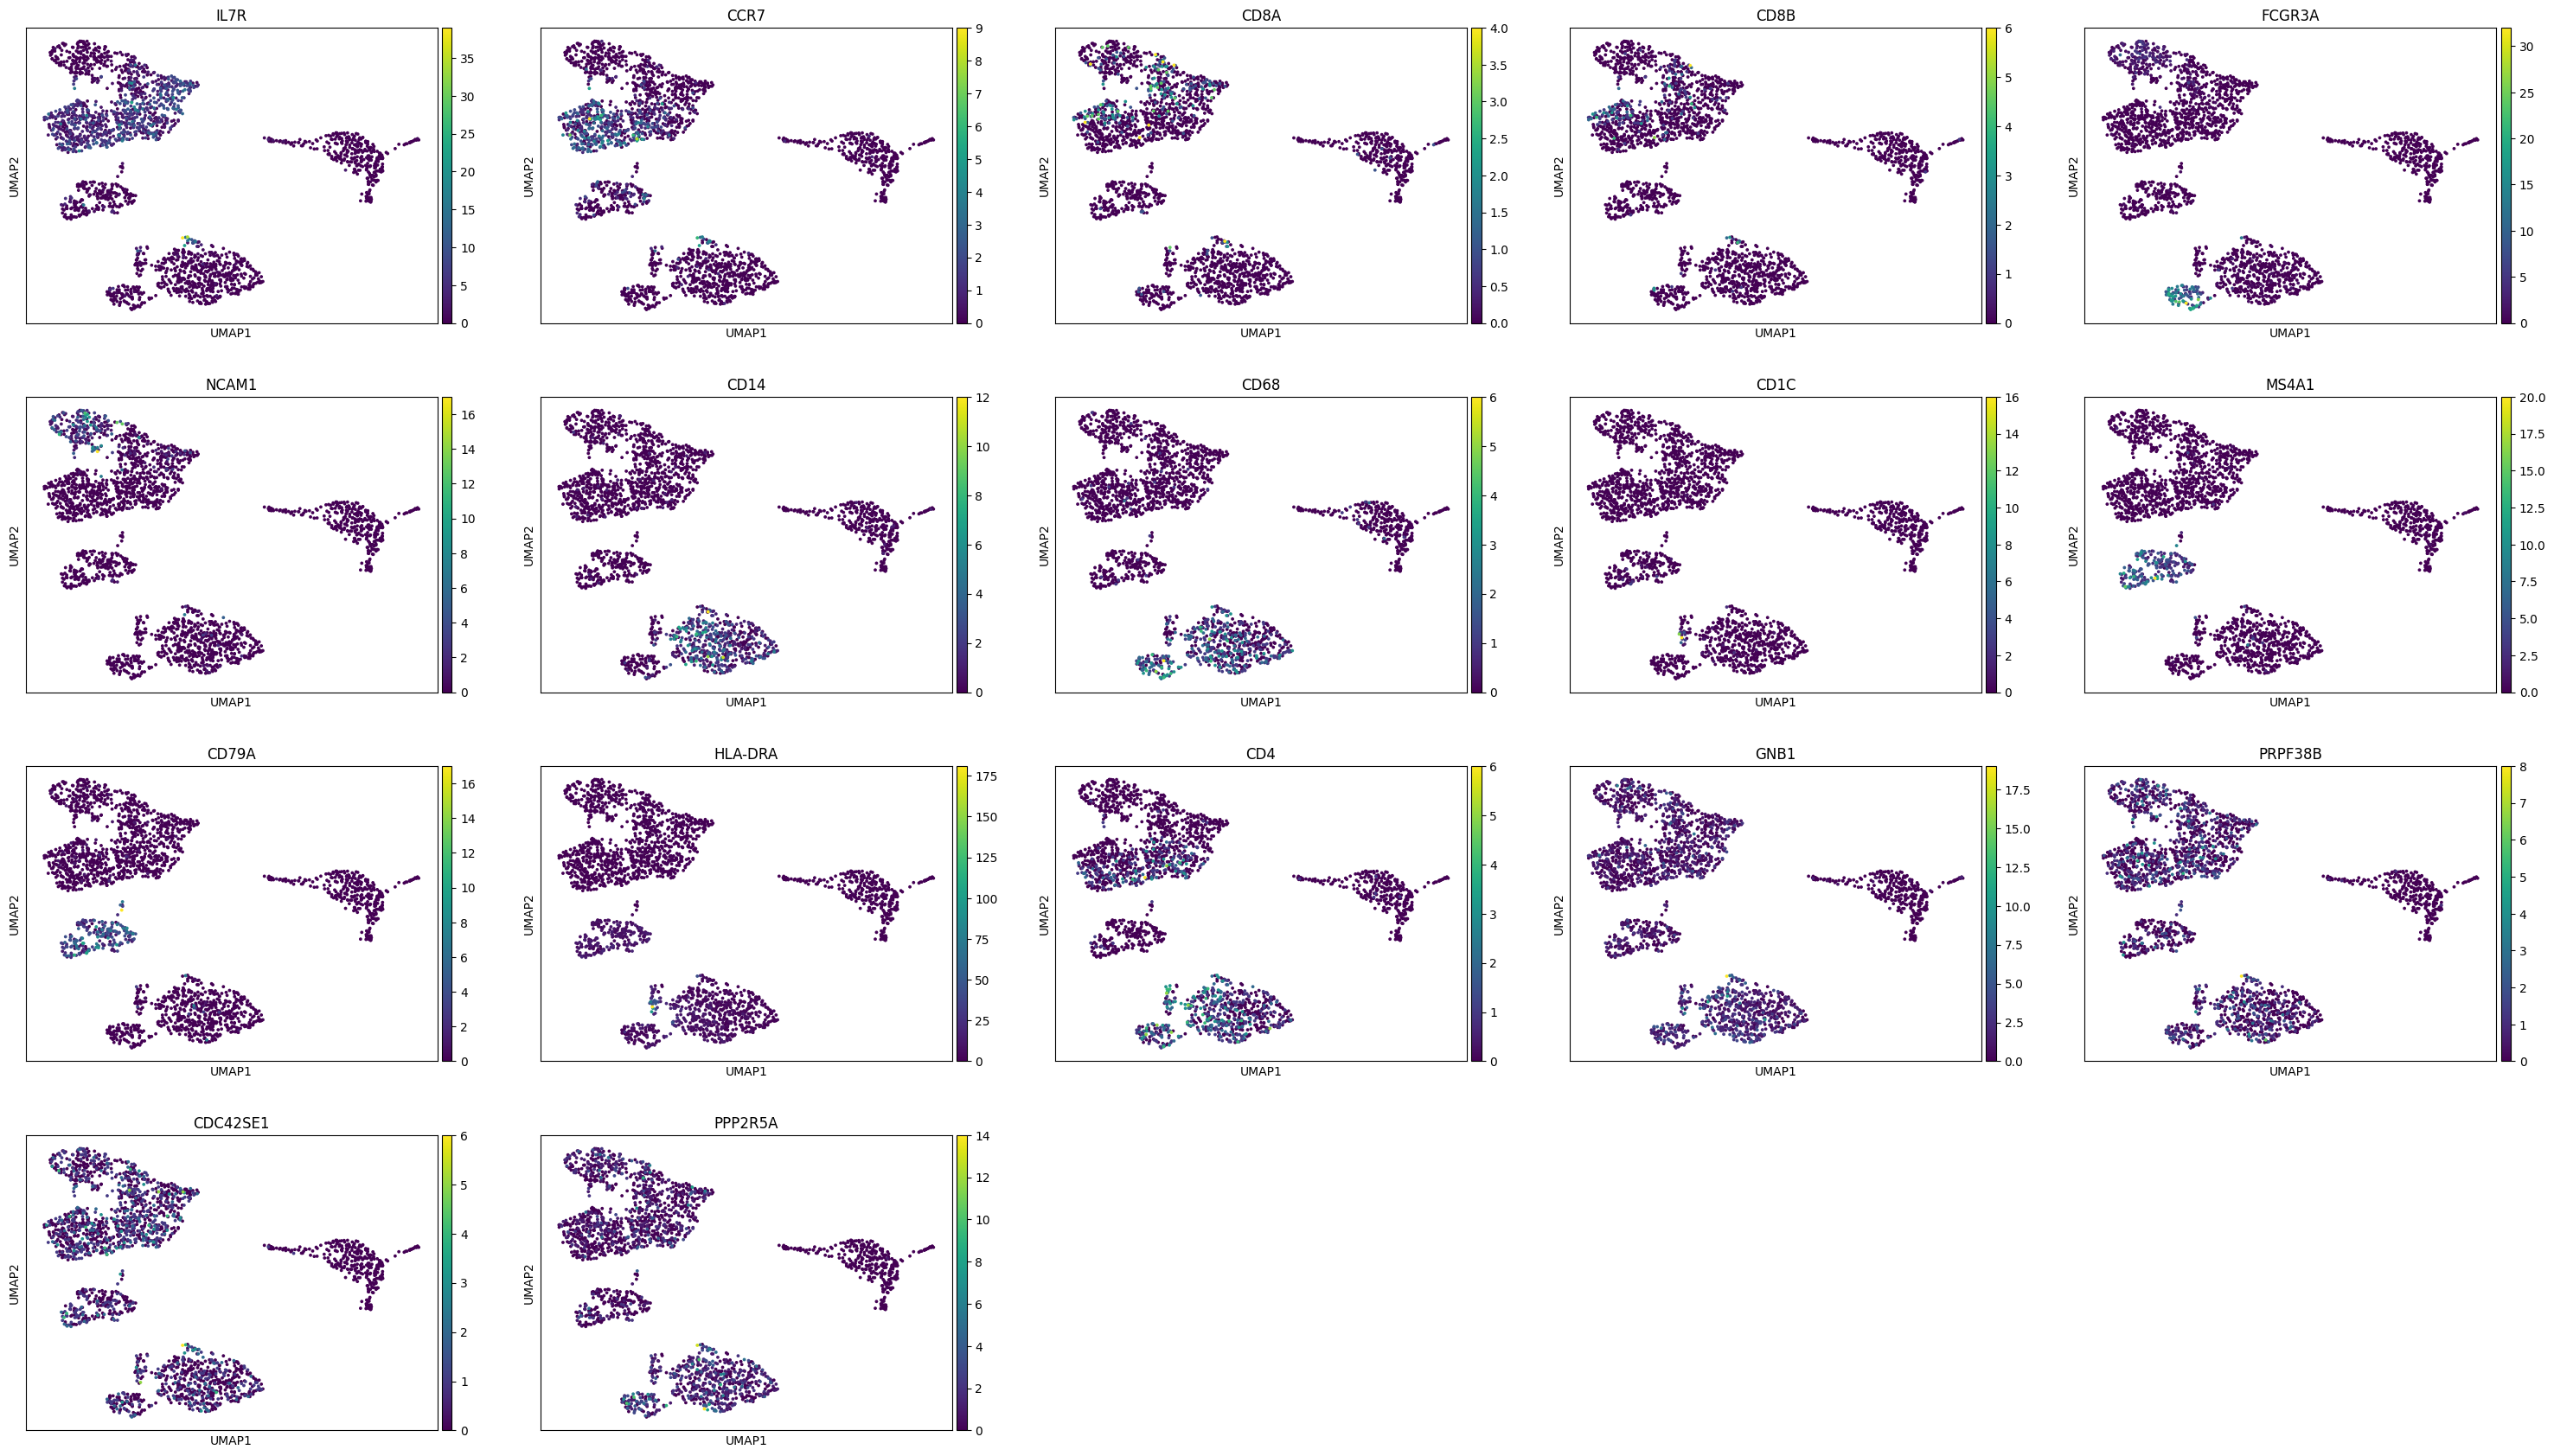

In [14]:
sc.pl.umap(h5_rna_union, color=marker_genes,  size=30, ncols=5)

In [15]:
## Save cluster average gene 
cluster_average_df = pd.DataFrame(index=h5_rna_union.var_names)

for c in h5_rna_union.obs['leiden_RNA_scVI_unionBC'].unique():
    a = h5_rna_union[h5_rna_union.obs['leiden_RNA_scVI_unionBC'] == c, :].layers['log1p_cpm'].mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()


gene_activity_file = os.path.join(Union_cell_subdir, '_SCVI_RNAanalysis', 'RNA_cluster_average_gene_expression.csv')
cluster_average_df.to_csv(gene_activity_file)

cluster_average_df.head()

,1,3,5,6,2,0,8,4,7,10,11,9
AL627309.1,0.006676,0.010664,0.000000,0.000000,0.000000,0.023448,0.028823,0.000000,0.017335,0.0,0.0,0.0
AL627309.5,0.018079,0.000000,0.017699,0.015902,0.005922,0.085301,0.071682,0.016718,0.086362,0.0,0.0,0.0
AL627309.4,0.000000,0.000000,0.000000,0.000000,0.000000,0.023221,0.017299,0.000000,0.030979,0.0,0.0,0.0
AL669831.2,0.009104,0.005188,0.013419,0.000000,0.004021,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
LINC01409,0.104900,0.084440,0.143812,0.139732,0.150061,0.165791,0.169336,0.000000,0.112358,0.0,0.0,0.0
